In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Math
from io import StringIO
from matplotlib.ticker import MultipleLocator
from IPython.display import Markdown

In [214]:
display(Markdown("""
# Atomistic simulations results
## PS in water
### Check equlibration
We calculated the convergence of the simulation parameters, such as potential energy, temperature, pressure of the system, and radius of gyration of PS.
Here, we discuss in detail of how we calculated radius of gyration of PS.
"""))


# Atomistic simulations results
## PS in water
### Check equlibration
We calculated the convergence of the simulation parameters, such as potential energy, temperature, pressure of the system, and radius of gyration of PS.
Here, we discuss in detail of how we calculated radius of gyration of PS.


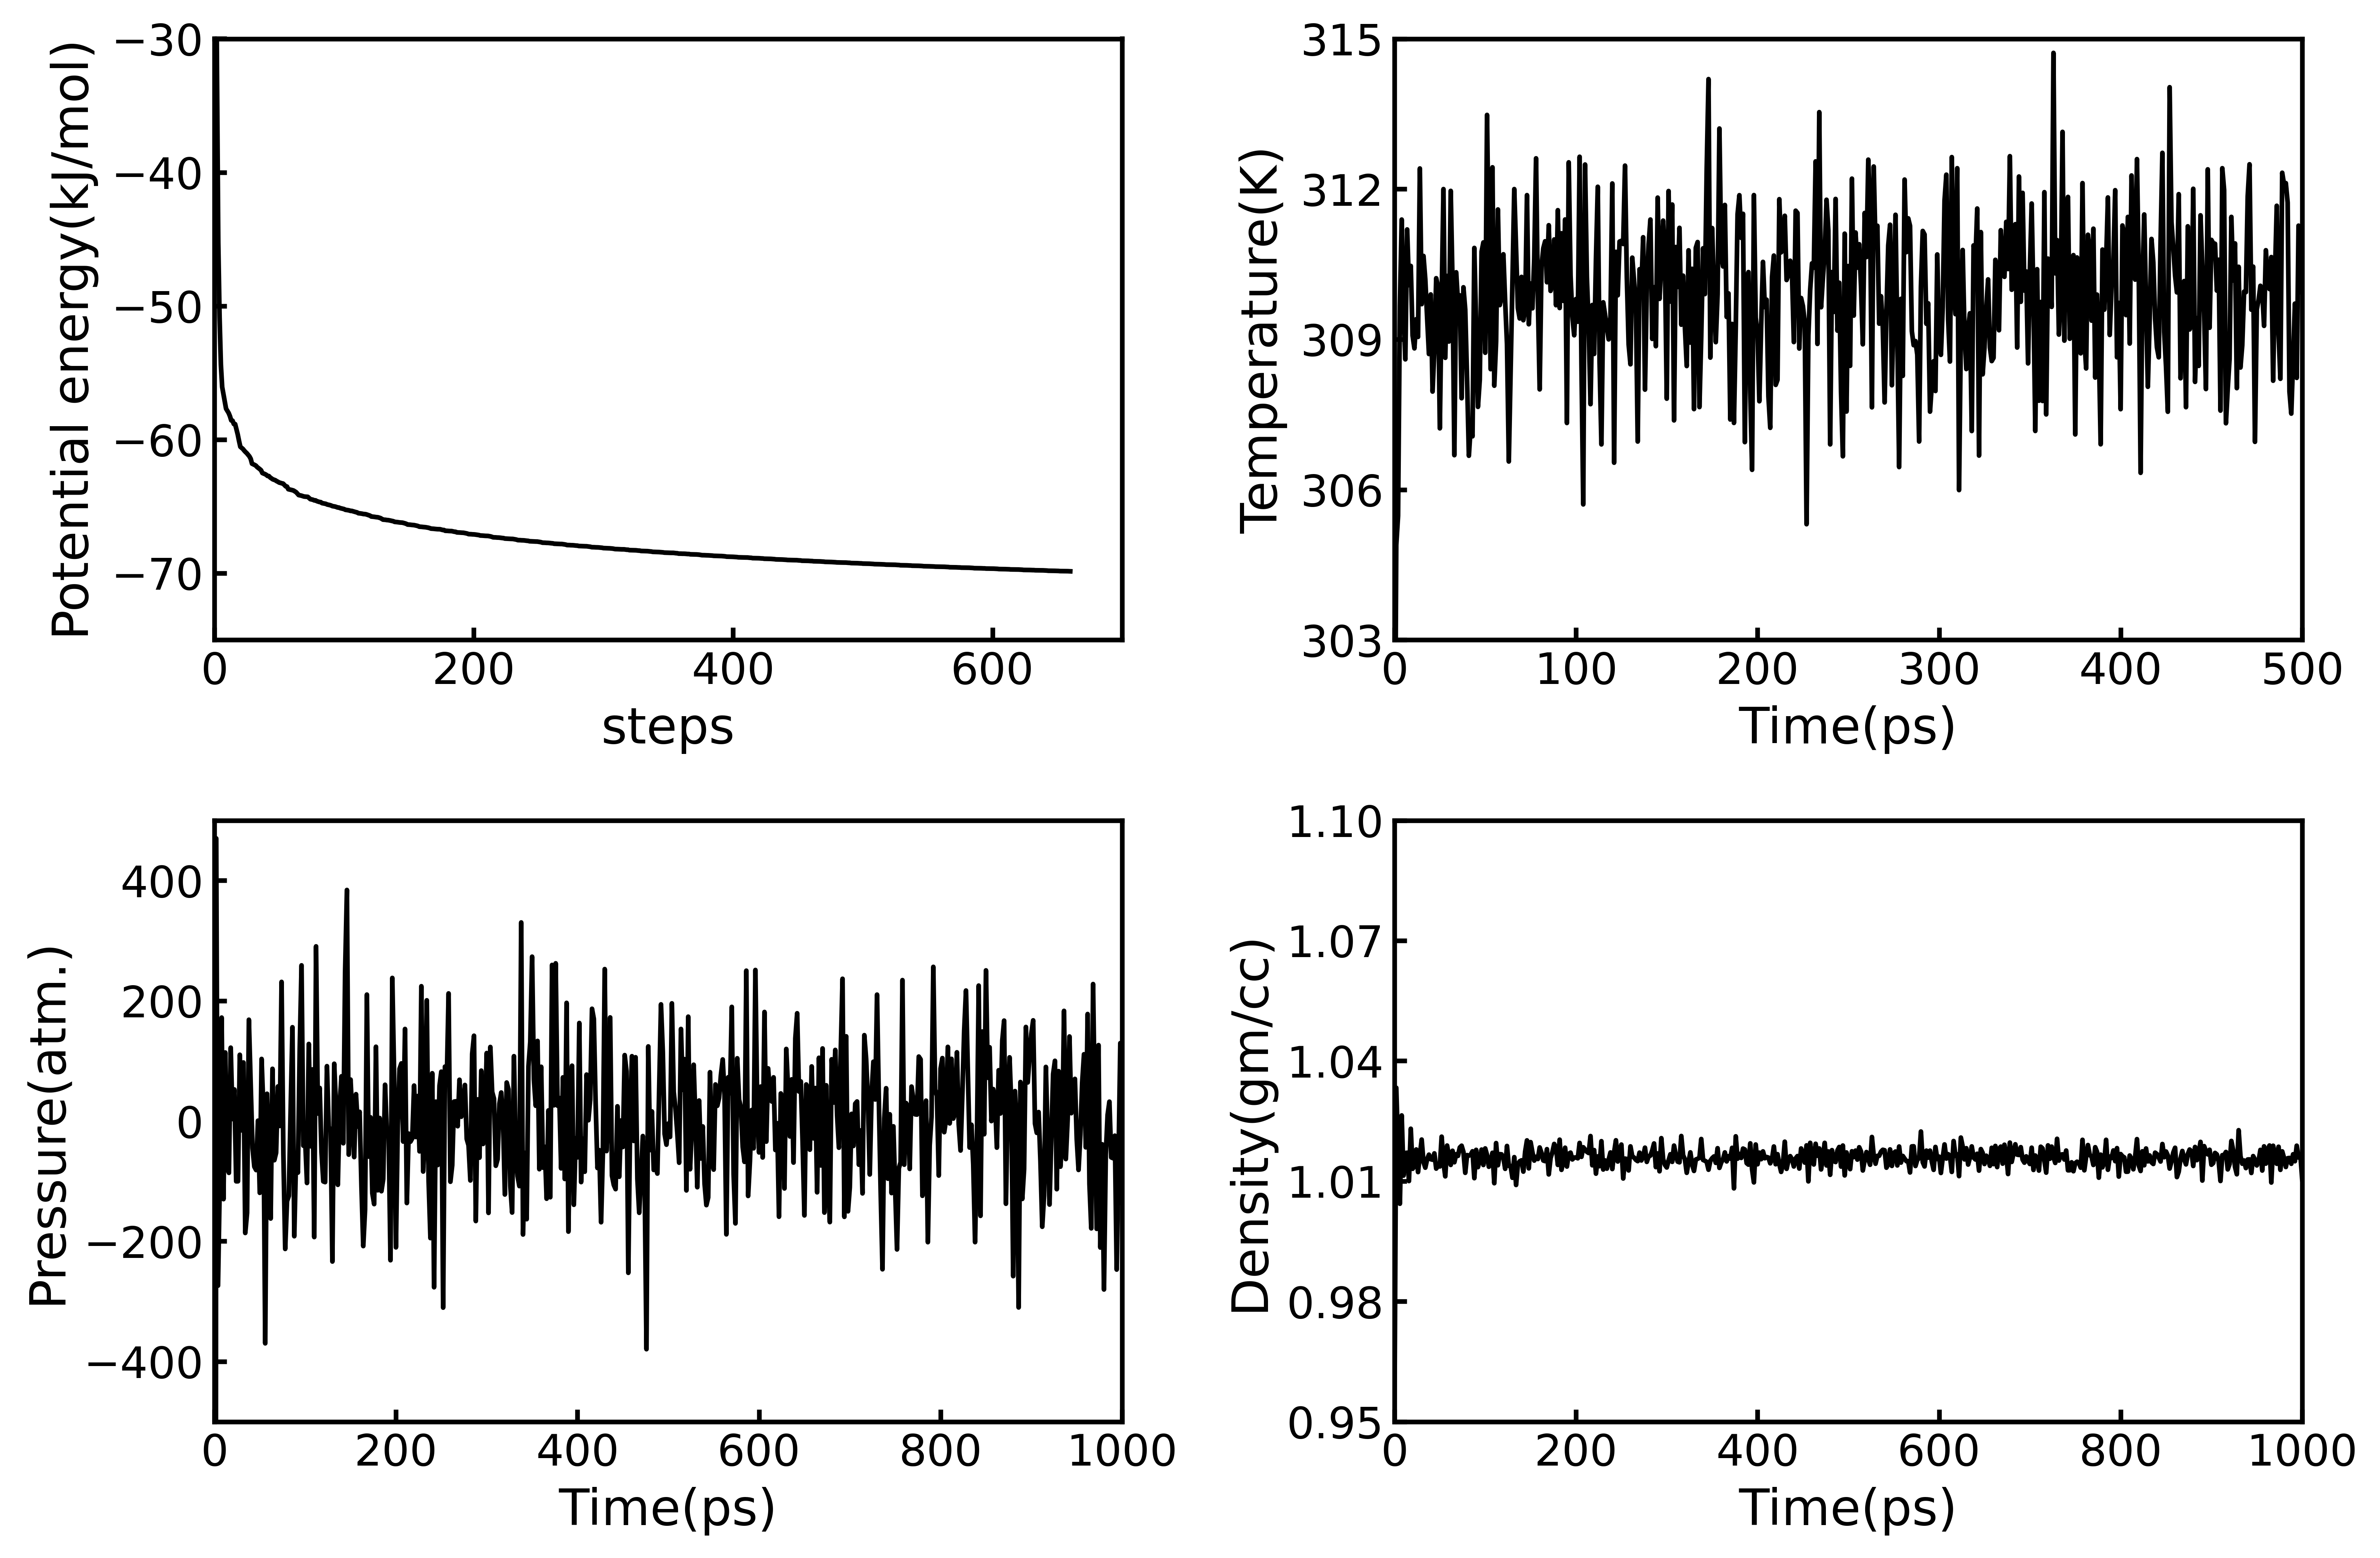

In [216]:
l1=['1.Atomistic_simulations/1.PS_in_water/analysis/potential_ps.xvg',
    '1.Atomistic_simulations/1.PS_in_water/analysis/temp_nvt_ps.xvg',
    '1.Atomistic_simulations/1.PS_in_water/analysis/pressure_npt_ps.xvg',
    '1.Atomistic_simulations/1.PS_in_water/analysis/density_npt_ps.xvg']

dfs=[]
for filename in l1:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df1=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None, usecols=[0, 1])
    #df1_col0=df1[0].values
    #df1_col1=df1[1].values
    #print(df1_col0)
    dfs.append(df1)
fig, axes=plt.subplots(2, 2, figsize=(12, 8), dpi=600)
axes=axes.flatten()
titles = ['Potential', 'Temperature', 'Pressure', 'Radius of Gyration']
labels=[('Potential energy(kJ/mol)', 'steps'), ('Temperature(K)', 'Time(ps)'),
        ('Pressure(atm.)', 'Time(ps)'), ('Density(gm/cc)', 'Time(ps)')]

dfs[0][1]=dfs[0][1]/10000.0
dfs[-1][1] = dfs[-1][1]/1000.0

xranges=[(0,700), (0,500), (0,1000), (0, 1000)]
yranges=[(-75,-30), (303,315), (-500,500), (0.95, 1.1)]
axes[1].set_yticks(np.arange(303, 316, 3))
axes[-1].set_yticks(np.arange(0.95, 1.1, 0.03))
plt.subplots_adjust(wspace=0.3, hspace=0.3) # Adjust the distnace between graphs
for ax, df, label, xr, yr in zip(axes, dfs, labels, xranges, yranges):
    ax.plot(df[0], df[1], color='black')
    #ax.set_title(title, fontsize=16)
    ax.set_xlim(xr[0], xr[1])
    ax.set_ylim(yr[0], yr[1])
    ax.set_xlabel(label[1], fontsize=16)
    ax.set_ylabel(label[0], fontsize=16)
    ax.tick_params(direction='in', labelsize=14, length=4, width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
plt.savefig('ps_water_equilibration.png', bbox_inches='tight', pad_inches=0.05, dpi=600)

In [217]:
display(Markdown("""
## PS in water
### Calculations of radius of gyration ($R_g$)
"""))

# Equation for Rg
display(Math(r"R_g = \sqrt{\frac{1}{N} \sum_{i=1}^{N} \left( \mathbf{r}_i - \mathbf{r}_{\text{com}} \right)^2 }"))

# Definitions of each term
display(Math(r"N: \text{Number of atoms in the molecule or group}"))
display(Math(r"\mathbf{r}_i: \text{Position vector of atom } i"))
display(Math(r"\mathbf{r}_{\text{com}}: \text{Position vector of the center of mass}"))
display(Math(r"R_g: \text{Radius of gyration (nm)}"))


## PS in water
### Calculations of radius of gyration ($R_g$)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

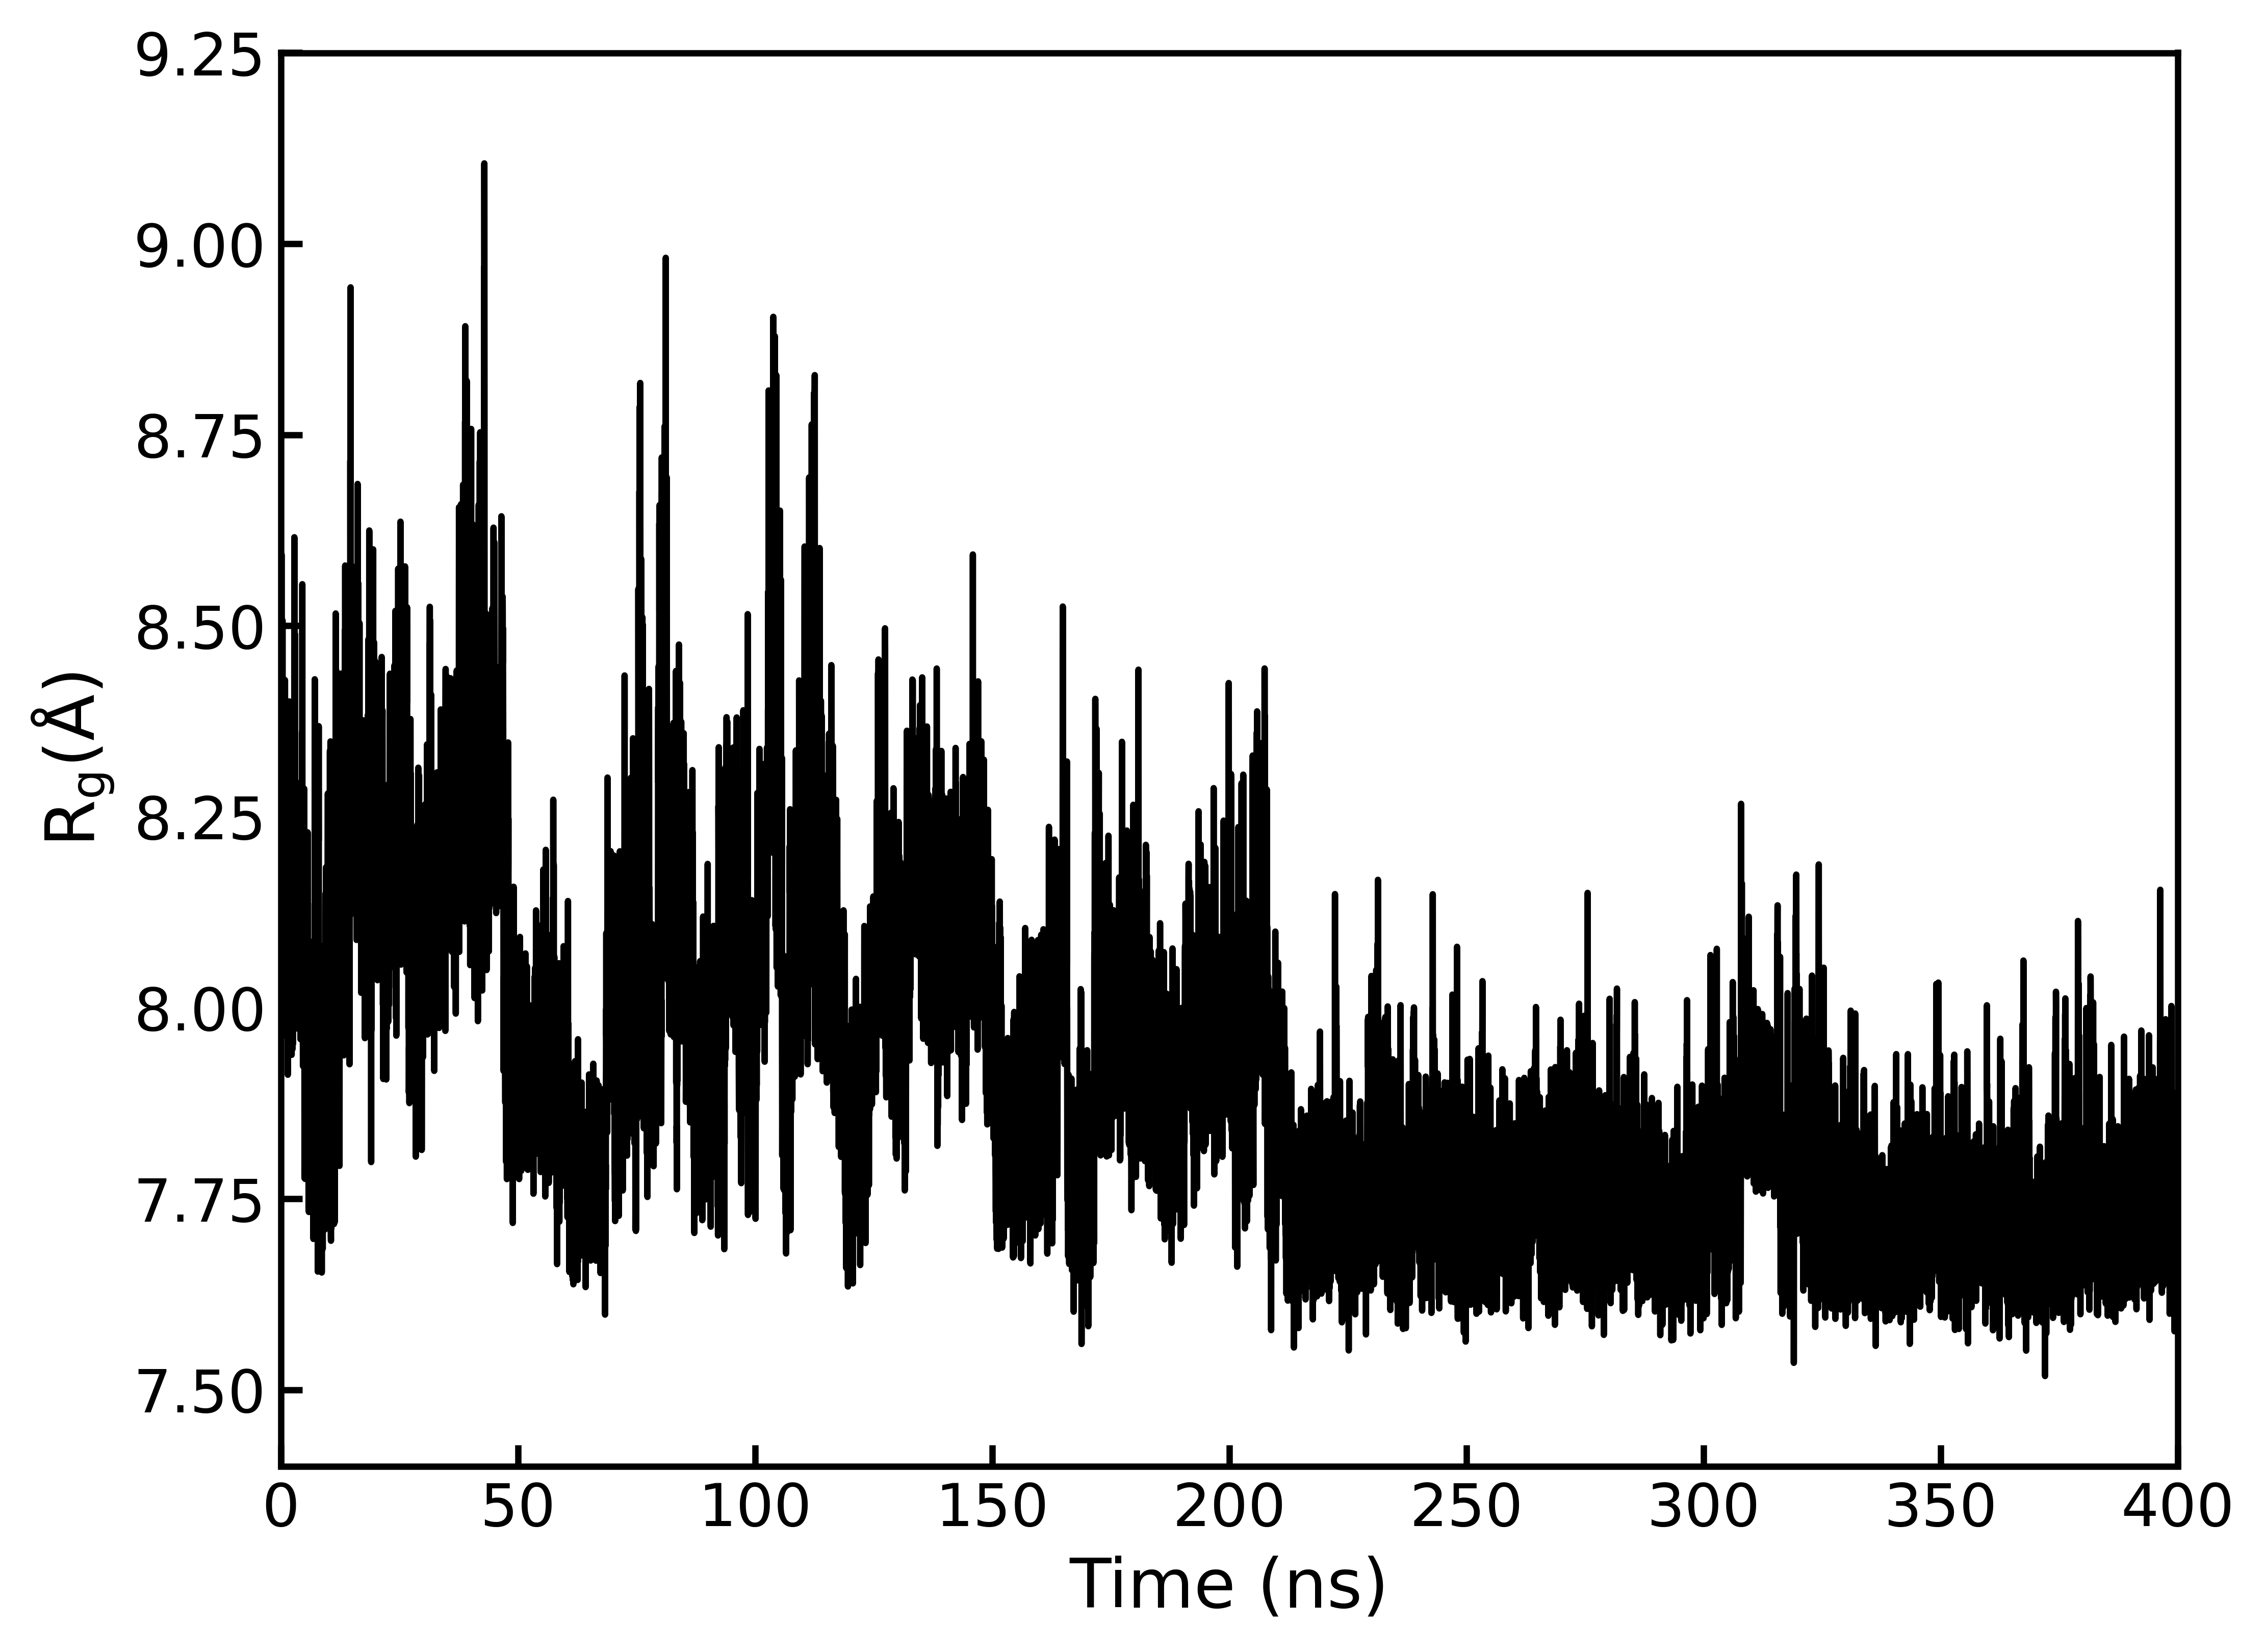

In [219]:
l1=['1.Atomistic_simulations/1.PS_in_water/analysis/rog_ps.xvg']
for filename in l1:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df1=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None)

#print(df1[1])
df1[0]=df1[0]/1000.0
df1[1]=df1[1]*10
fig, ax = plt.subplots(1,1, figsize=(8, 6), dpi=600)
ax.plot(df1[0], df1[1], color='black')
ax.set_ylim(7.4, 9.25)
ax.set_xlim(0, 400)
ax.set_xlabel('Time (ns)', fontsize=16)
ax.set_ylabel('R$\mathrm{_g}(\mathrm{\AA}$)', fontsize=16)
ax.tick_params(direction='in', labelsize=14, length=5, width=1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
plt.savefig('RoG_PS_isolated.png',bbox_inches='tight', pad_inches=0.05, dpi=600)

In [220]:
display(Markdown("""
## POPC in water
### Check if the system is well equilibrated
"""))


## POPC in water
### Check if the system is well equilibrated


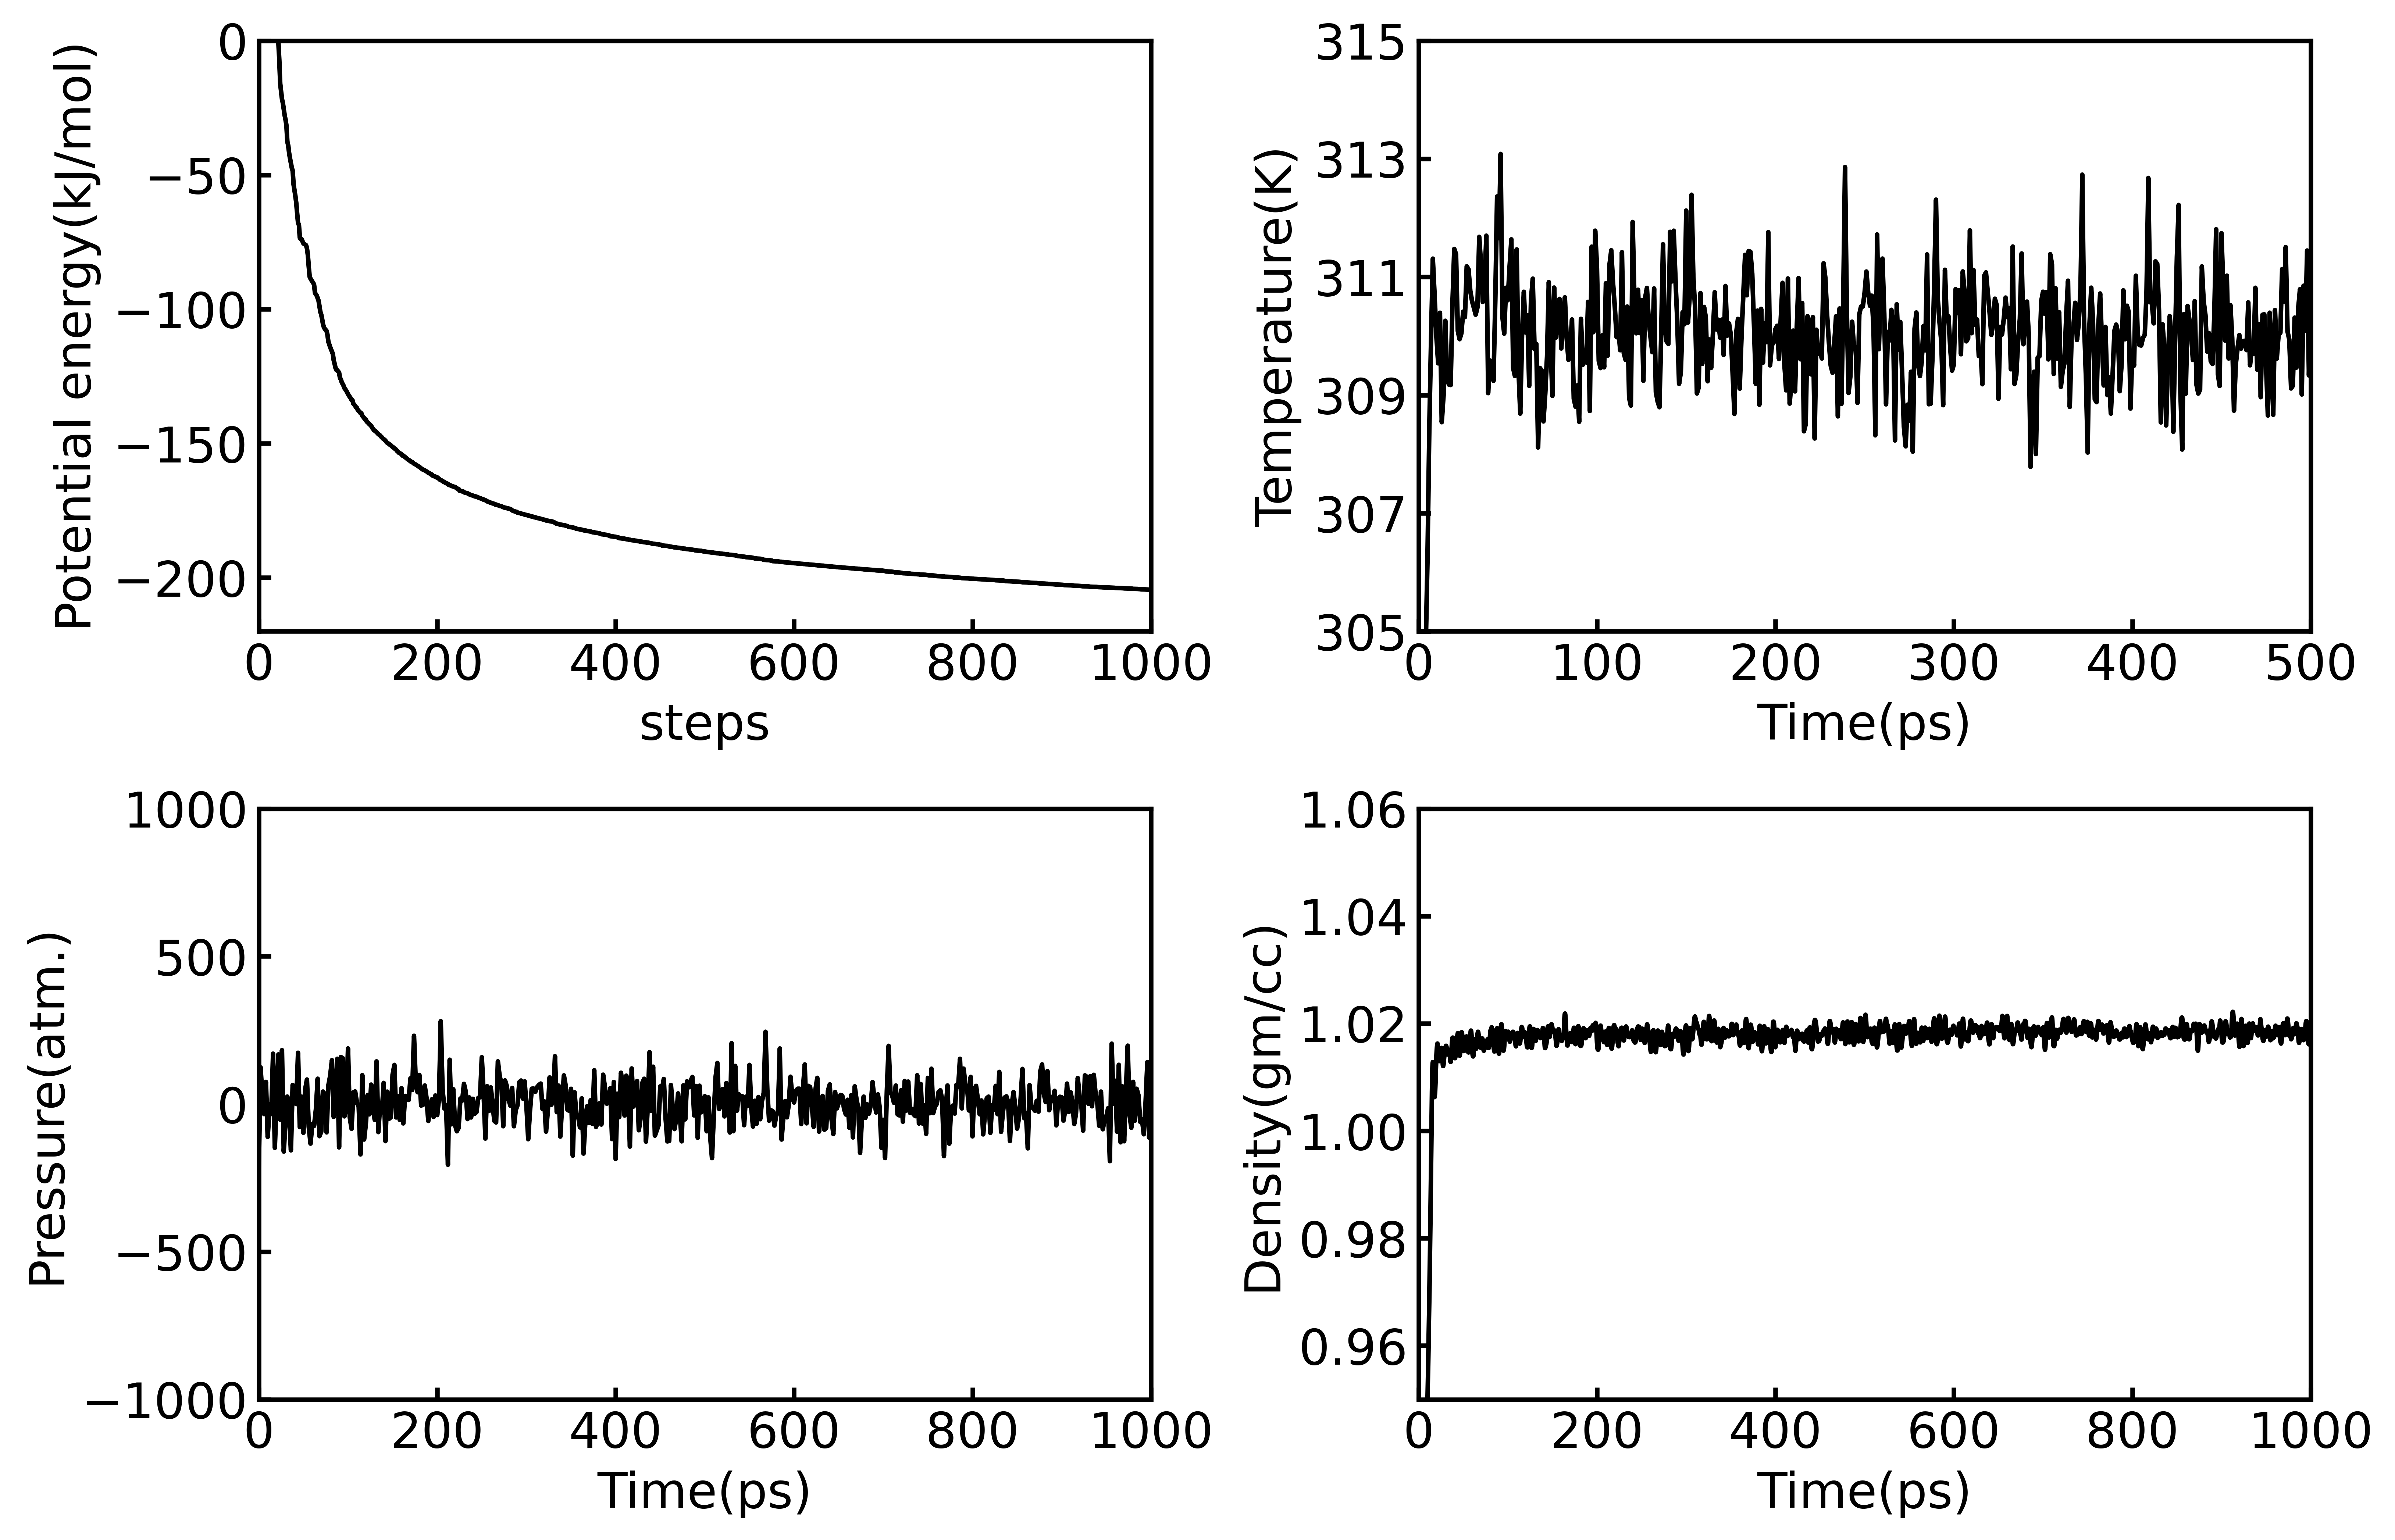

In [222]:
l1=['1.Atomistic_simulations/2.POPC_in_water/analysis/equilibration_parameters/potential_popc.xvg', 
    '1.Atomistic_simulations/2.POPC_in_water/analysis/equilibration_parameters/temp_nvt_popc.xvg',
    '1.Atomistic_simulations/2.POPC_in_water/analysis/equilibration_parameters/press_npt_popc.xvg',
    '1.Atomistic_simulations/2.POPC_in_water/analysis/equilibration_parameters/density_npt_popc.xvg']

dfs=[]
for filename in l1:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df1=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None, usecols=[0, 1])
    #df1_col0=df1[0].values
    #df1_col1=df1[1].values
    #print(df1_col0)
    dfs.append(df1)
fig, axes=plt.subplots(2, 2, figsize=(12, 8), dpi=600)
axes=axes.flatten()
#titles = ['Potential', 'Temperature', 'Pressure', 'Radius of Gyration']
labels=[('Potential energy(kJ/mol)', 'steps'), ('Temperature(K)', 'Time(ps)'),
        ('Pressure(atm.)', 'Time(ps)'), ('Density(gm/cc)', 'Time(ps)')]

dfs[0][1]=dfs[0][1]/10000.0
dfs[1][0]=dfs[1][0]*5.0
dfs[-1][1]=dfs[-1][1]*0.001

dfs[2] = dfs[2].iloc[::10].reset_index(drop=True) #skip every 10 data points from 3rd graph
xranges=[(0,1000), (0,500), (0,1000), (0, 1000)]
yranges=[(-220,0), (305,315), (-1000,1000), (0.95, 1.06)]

axes[1].set_yticks(np.arange(305, 316, 2))
colors=['black', 'black', 'black', 'black']
plt.subplots_adjust(wspace=0.3, hspace=0.3) # Adjust the distnace between graphs
for ax, df, label, xr, yr, col in zip(axes, dfs, labels, xranges, yranges, colors):
    ax.plot(df[0], df[1], color=col)
    #ax.set_title(title, fontsize=16)
    ax.set_xlim(xr[0], xr[1])
    ax.set_ylim(yr[0], yr[1])
    ax.set_xlabel(label[1], fontsize=16)
    ax.set_ylabel(label[0], fontsize=16)
    ax.tick_params(direction='in', labelsize=16, length=4, width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
plt.savefig('popc_water_equilibration.png', bbox_inches='tight', pad_inches=0.05, dpi=600)


## POPC in water
### Analysis


<IPython.core.display.Math object>

<IPython.core.display.Math object>

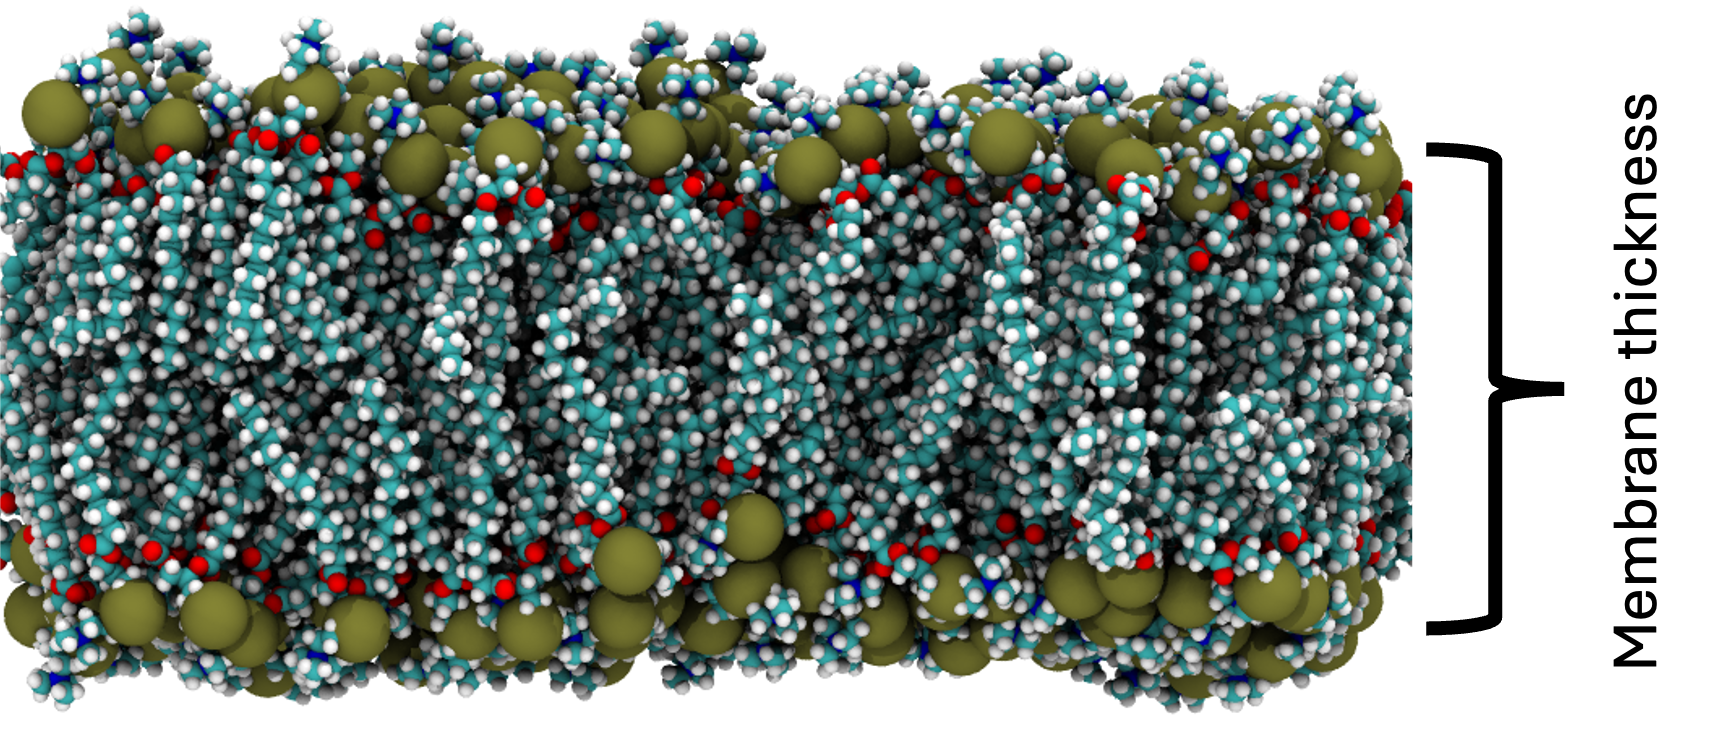

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

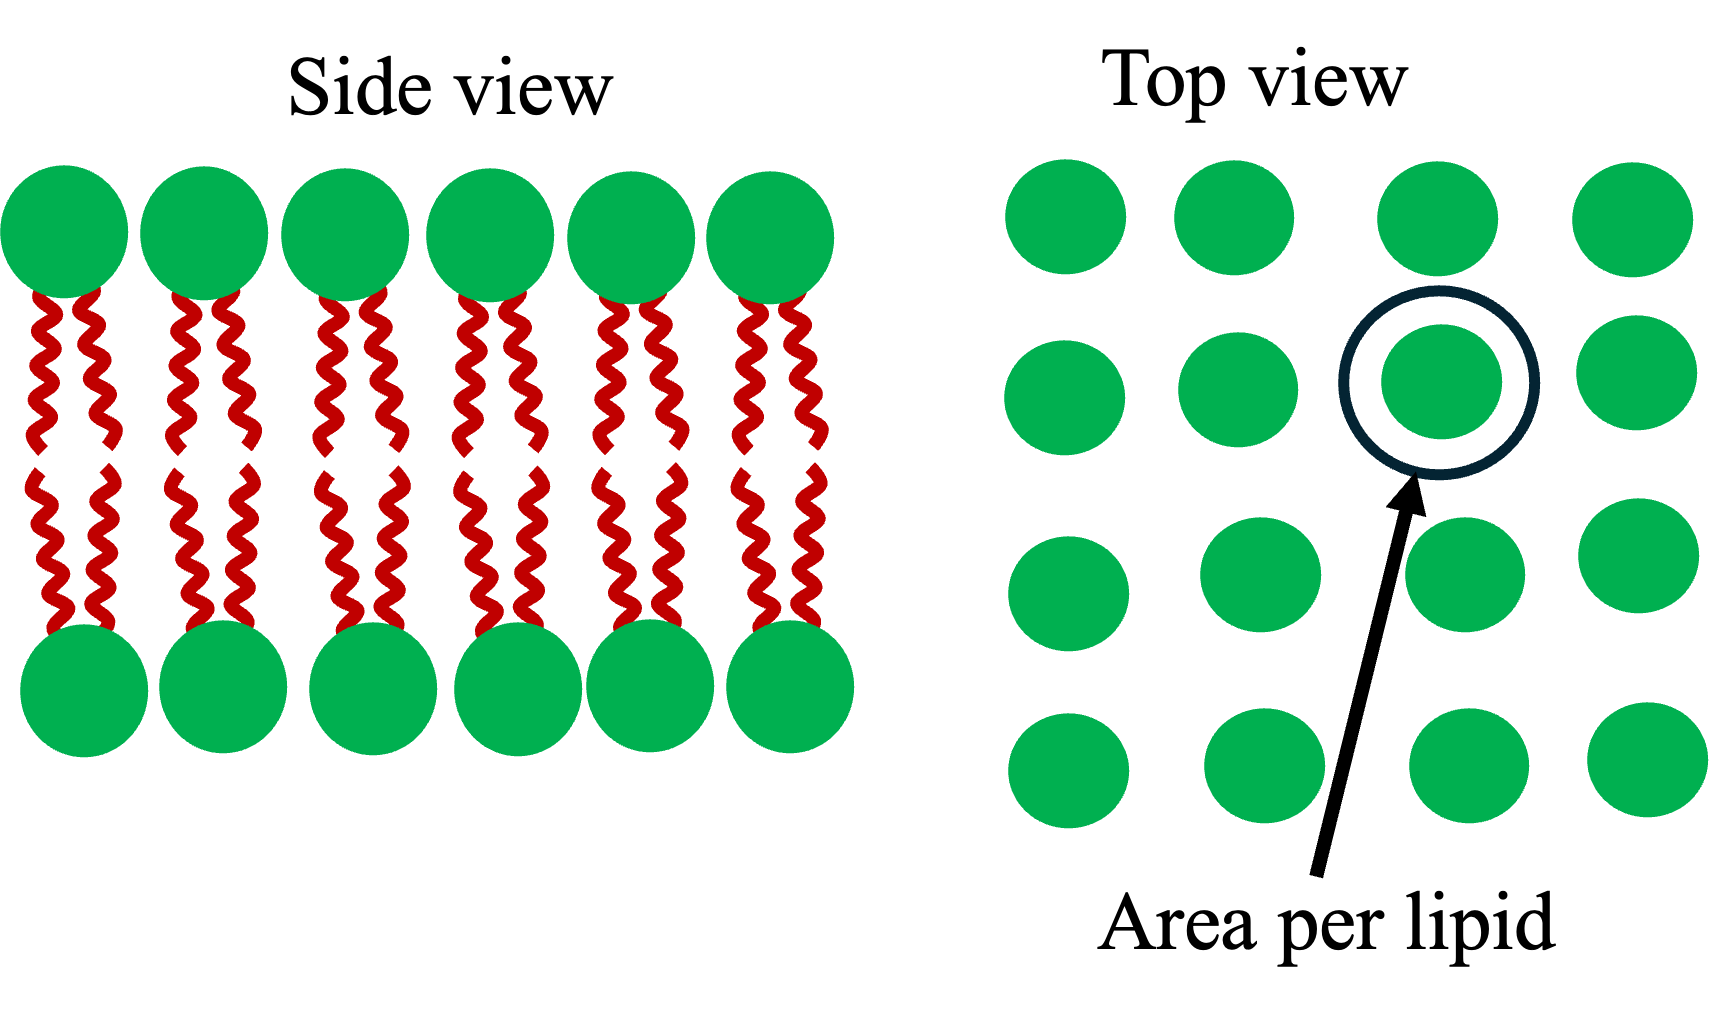

In [223]:
display(Markdown("""
## POPC in water
### Analysis
"""))
from IPython.display import Image, display
display(Math(r"\textbf{1. Calculations of membrane thickness}"))
display(Math(r"\text{Membrane thickness was defined as the average distance between" 
r"the phosphorus atoms in the upper and lower leaflets of the lipid bilayer.}"))
display(Image(filename='1.Atomistic_simulations/mem_thickness.png', width=400, height=300))

display(Math(r" \textbf{2. Calculations of area per lipid of the membrane}"))

display(Math(r"A_{\text{lipid}} = \frac{L_x \times L_y}{N_{\text{lipid}}}"))
# Display the variable meanings
display(Math(r"L_x: \text{box length in x-direction (nm)}"))
display(Math(r"L_y: \text{box length in y-direction (nm)}"))
display(Math(r"N_{\text{lipid}}: \text{number of lipids in one leaflet}"))
display(Math(r"A_{\text{lipid}}: \text{area per lipid (nm}^2\text{)}"))
display(Math(r"\text{A schematic representation of the area per lipid is shown below:}"))
display(Image(filename='1.Atomistic_simulations/apl_schematic.png', width=400, height=300))

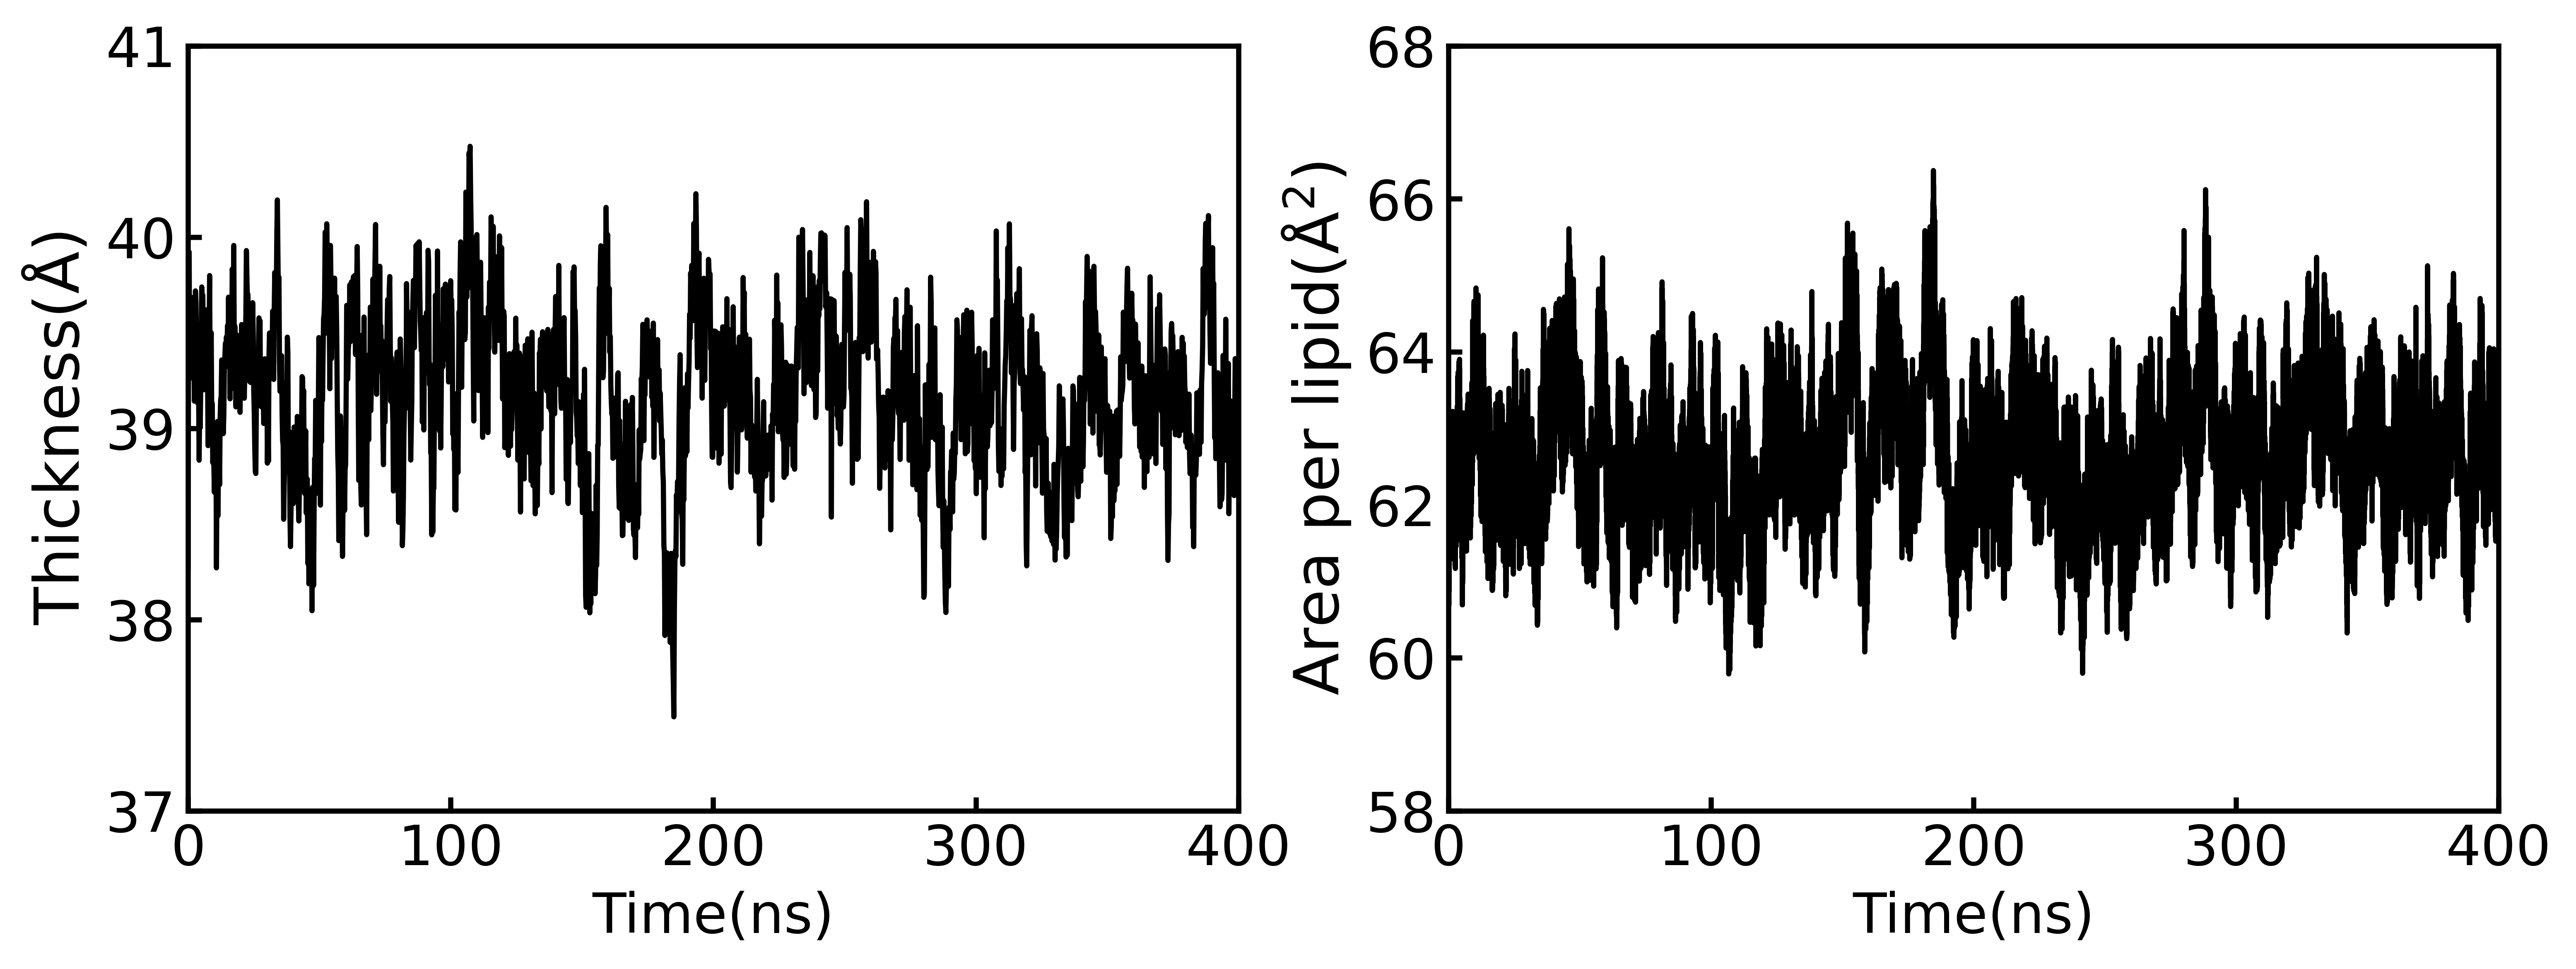

In [225]:
file1=['1.Atomistic_simulations/2.POPC_in_water/analysis/mem_thickness/P-P_distance_popc.dat']
for filename in file1:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df0=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None, usecols=[0, 1])

df0[0]=(df0[0]*2)/10
file2=['1.Atomistic_simulations/2.POPC_in_water/analysis/apl/box_XY_0_400ns.xvg']
for filename in file2:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df2=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None)
apl=((df2[1]*df2[2])/200.0)*100.0
df2[0]=df2[0]/1000

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=600)
axes=axes.flatten()

ax[0].plot(df0[0], df0[1], color='black')
ax[1].plot(df2[0], apl, color='black')
ax[0].set_xlim(0, 400)
ax[1].set_xlim(0, 400)
ax[0].set_ylim(37, 41)
ax[1].set_ylim(58, 68)
ax[0].set_xlabel('Time(ns)', fontsize=16)
ax[0].set_ylabel('Thickness($\mathrm{\AA}$)', fontsize=18)
ax[1].set_xlabel('Time(ns)', fontsize=16)
ax[1].set_ylabel('Area per lipid($\mathrm{\AA}^2$)', fontsize=18)
ax[0].set_yticks(np.arange(37, 42, 1))
ax[1].set_yticks(np.arange(58, 69, 2))
#plt.tight_layout()
ax[0].tick_params(direction='in', labelsize=16, length=4, width=1.5)
ax[1].tick_params(direction='in', labelsize=16, length=4, width=1.5)
for spine in ax[0].spines.values():
    spine.set_linewidth(1.5)
for spine in ax[1].spines.values():
    spine.set_linewidth(1.5)
plt.savefig('popc_water_analysis.png', bbox_inches='tight', pad_inches=0.05, dpi=600)

In [226]:
display(Markdown("""
## Calculations of order parameter
"""))
# Display the op equation
display(Math(r"S_{CD} = \left\langle \frac{3\cos^2\theta - 1}{2} \right\rangle"))

# Display variable definitions
display(Math(r"\theta: \text{Angle between C–H bond vector and membrane normal (usually z-axis)}"))
display(Math(r"\left\langle \cdots \right\rangle: \text{Average over time and ensemble}"))
display(Math(r"S_{CD}: \text{Deuterium order parameter (ranges from -0.5 to 1)}"))


## Calculations of order parameter


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

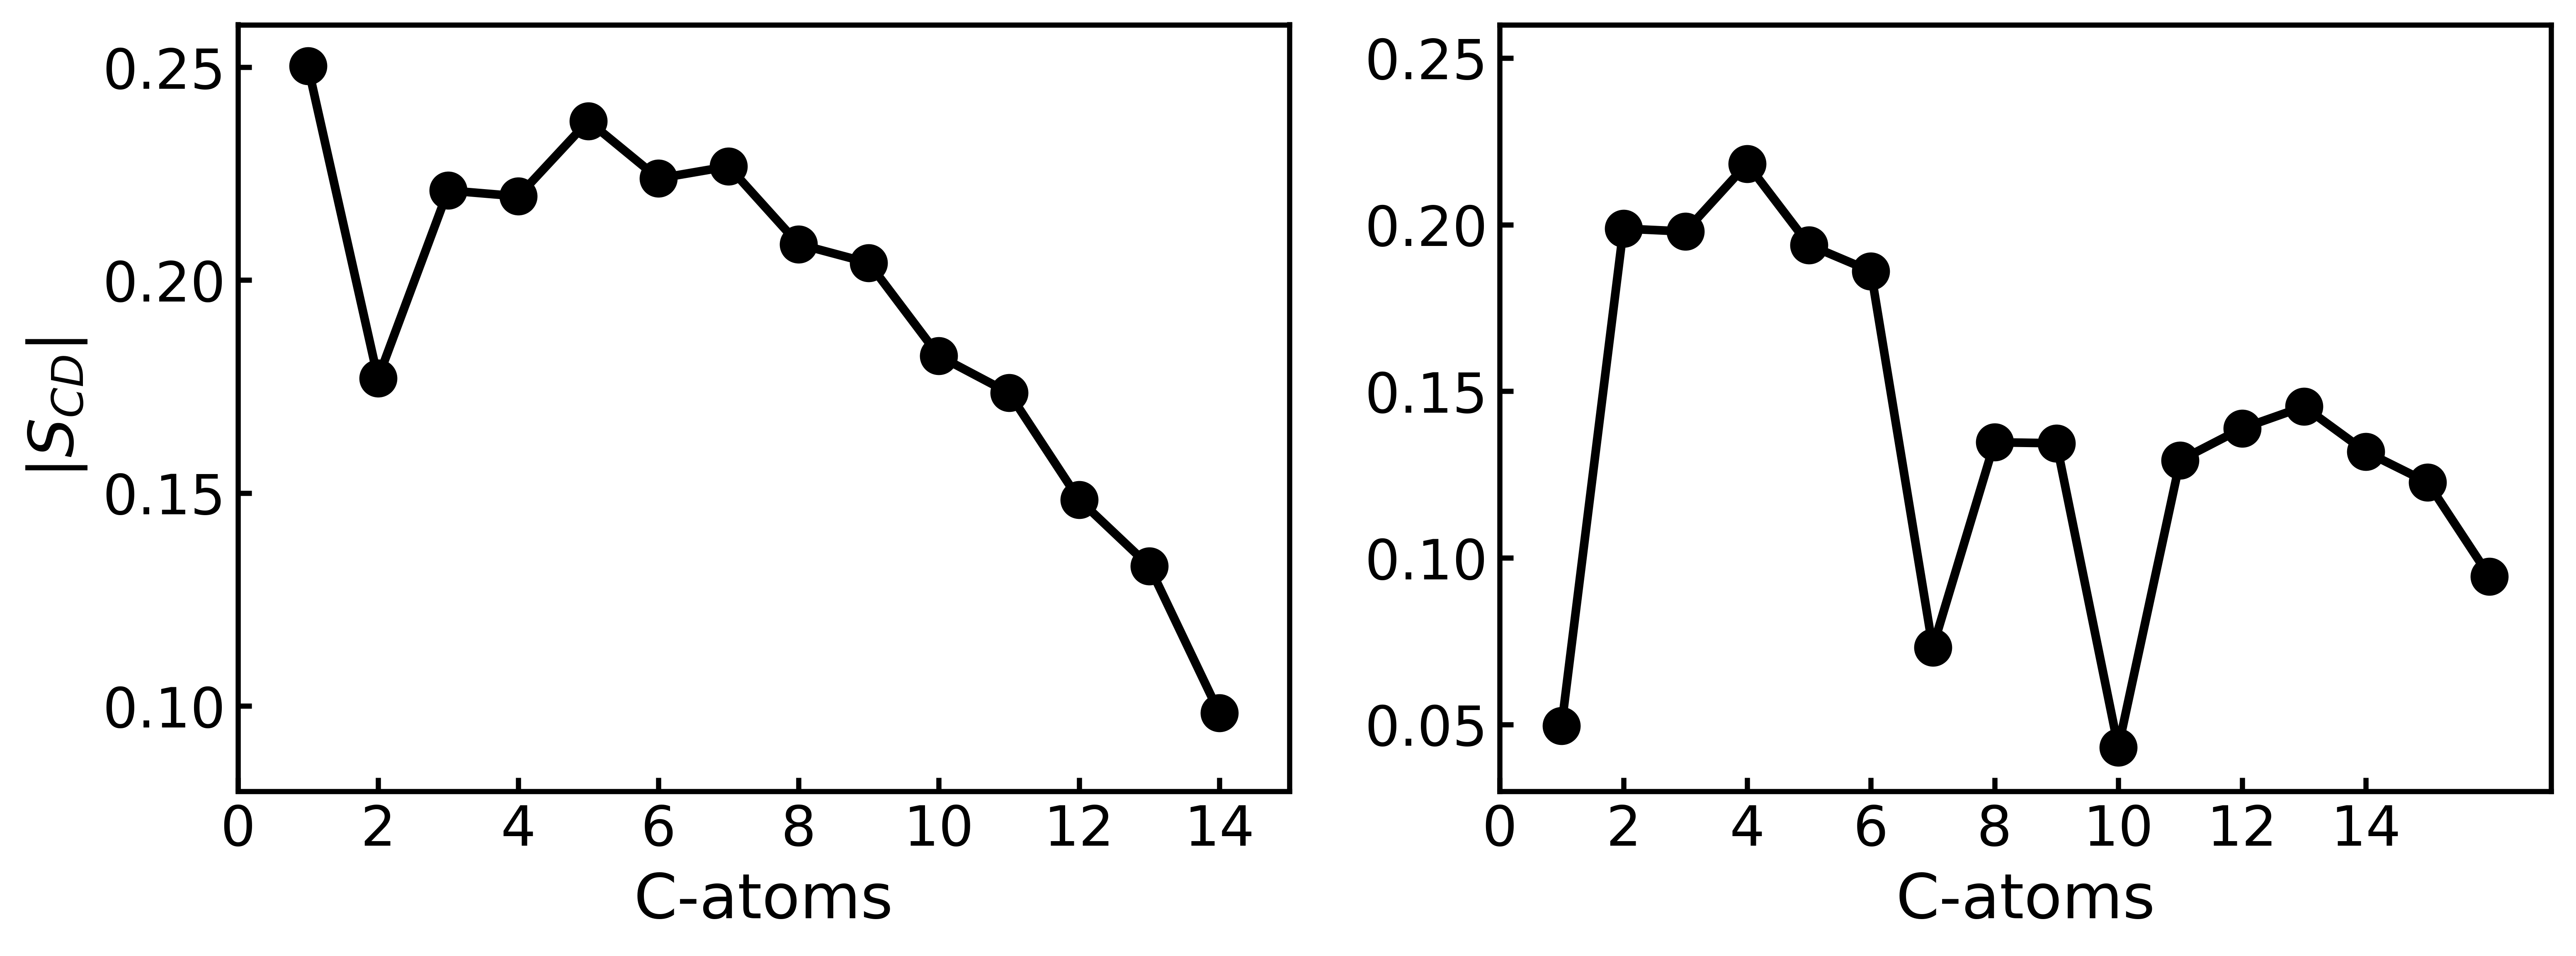

In [228]:
dfs=[]
file3=['1.Atomistic_simulations/2.POPC_in_water/analysis/order_parameter/op_sn1_popc.xvg',
       '1.Atomistic_simulations/2.POPC_in_water/analysis/order_parameter/op_sn2_popc.xvg']
for file in file3:
    with open(file) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df3=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None, usecols=[0,1])
    dfs.append(df3)
dfs[0][1]=dfs[0][1]*-1
dfs[1][1]=dfs[1][1]*-1
#print(dfs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=600)
axes[0].set_ylim(0.08, 0.26)
axes[1].set_ylim(0.03, 0.26)
axes[0].set_xlim(0, 15)
axes[1].set_xlim(0, 17)
axes[0].set_ylabel('$|S_{CD}|$', fontsize=18)
#axx[0].set_yticks(np.arange(0.08, 0.27, 0.03))

for axx, df in zip(axes, dfs):
    axx.plot(df[0], df[1], color='black', marker='o', markersize=10, linewidth=2.5)
    axx.tick_params(direction='in', labelsize=16, length=4, width=1.5)
    axx.set_xticks(np.arange(0, 15, 2))
    axx.set_xlabel('C-atoms', fontsize=18)
    #plt.tight_layout()
    for spine in axx.spines.values():
        spine.set_linewidth(1.5)
plt.savefig('popc_water_op.png', bbox_inches='tight', pad_inches=0.05, dpi=600)

In [229]:
display(Markdown("""
## POPC-PS in water
### Analysis
"""))


## POPC-PS in water
### Analysis


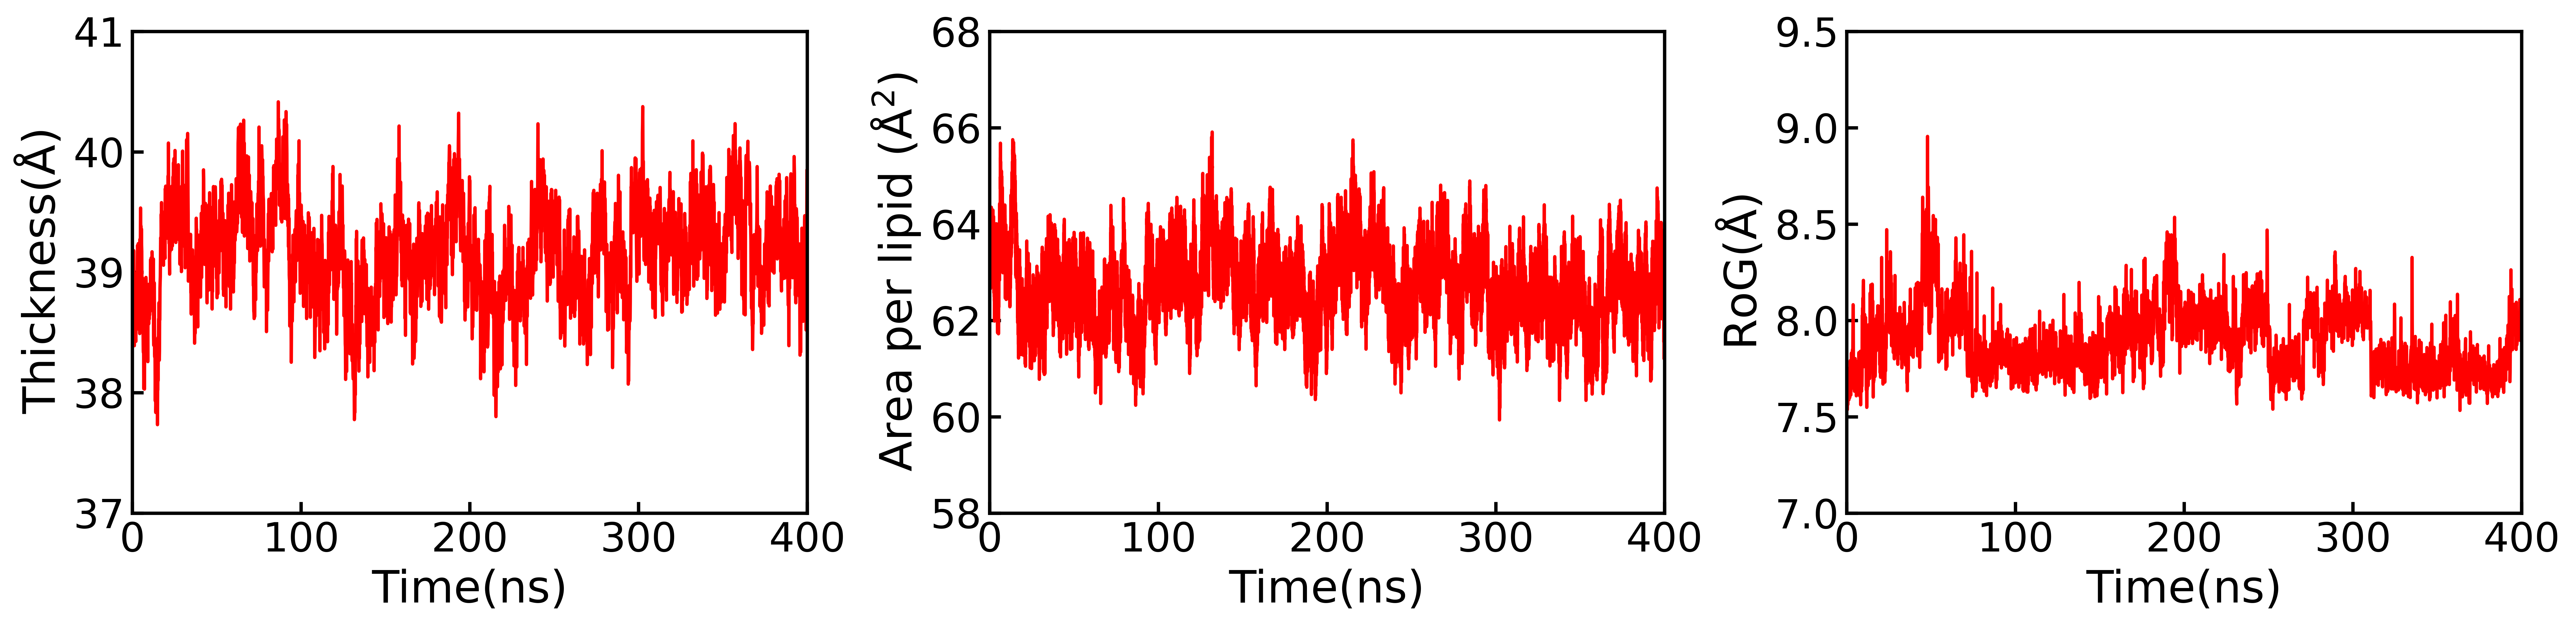

In [237]:
file=['1.Atomistic_simulations/3.POPC-PS/analysis/mem_thickness/P-P_distance_popc-ps.dat',
      '1.Atomistic_simulations/3.POPC-PS/analysis/apl/apl_trj_popc-ps.dat', 
      '1.Atomistic_simulations/3.POPC-PS/analysis/rog/rog_PS_popc-ps.xvg']
dfs=[]
for filename in file:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df1=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None, usecols=[0, 1])
    #print(df1[0])
    dfs.append(df1)
#print(dfs)
dfs[1][1]=dfs[1][1]*100
dfs[2][1]=dfs[2][1]*10


fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=600)
axes=axes.flatten()

x_scale=[0.1, 0.001, 0.001, 0.01]
labels=[('Thickness($\mathrm{\AA}$)', 'Time(ns)'), ('Area per lipid ($\mathrm{\AA}^2$)', 'Time(ns)'),
        ('RoG($\mathrm{\AA}$)', 'Time(ns)'), ('RoG($\mathrm{\AA}$)', 'Time(ns)')]

yranges=[(37, 41), (58, 68), (7, 9.5)]
axes[0].set_yticks(np.arange(37, 42, 1))
axes[1].set_yticks(np.arange(58, 69, 2))
for ax, df, yr, xs, label in zip(axes, dfs, yranges, x_scale, labels):
    ax.plot(df[0]*xs, df[1], color='red')
    ax.set_ylim(yr[0], yr[1])
    ax.set_xlim(0, 400)
    ax.set_xlabel(label[1], fontsize=20)
    ax.set_ylabel(label[0], fontsize=20)
    plt.tight_layout()
    ax.tick_params(direction='in', labelsize=18, length=5, width=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
plt.savefig('popc-ps_water_analysis.png', bbox_inches='tight', pad_inches=0.05, dpi=600)

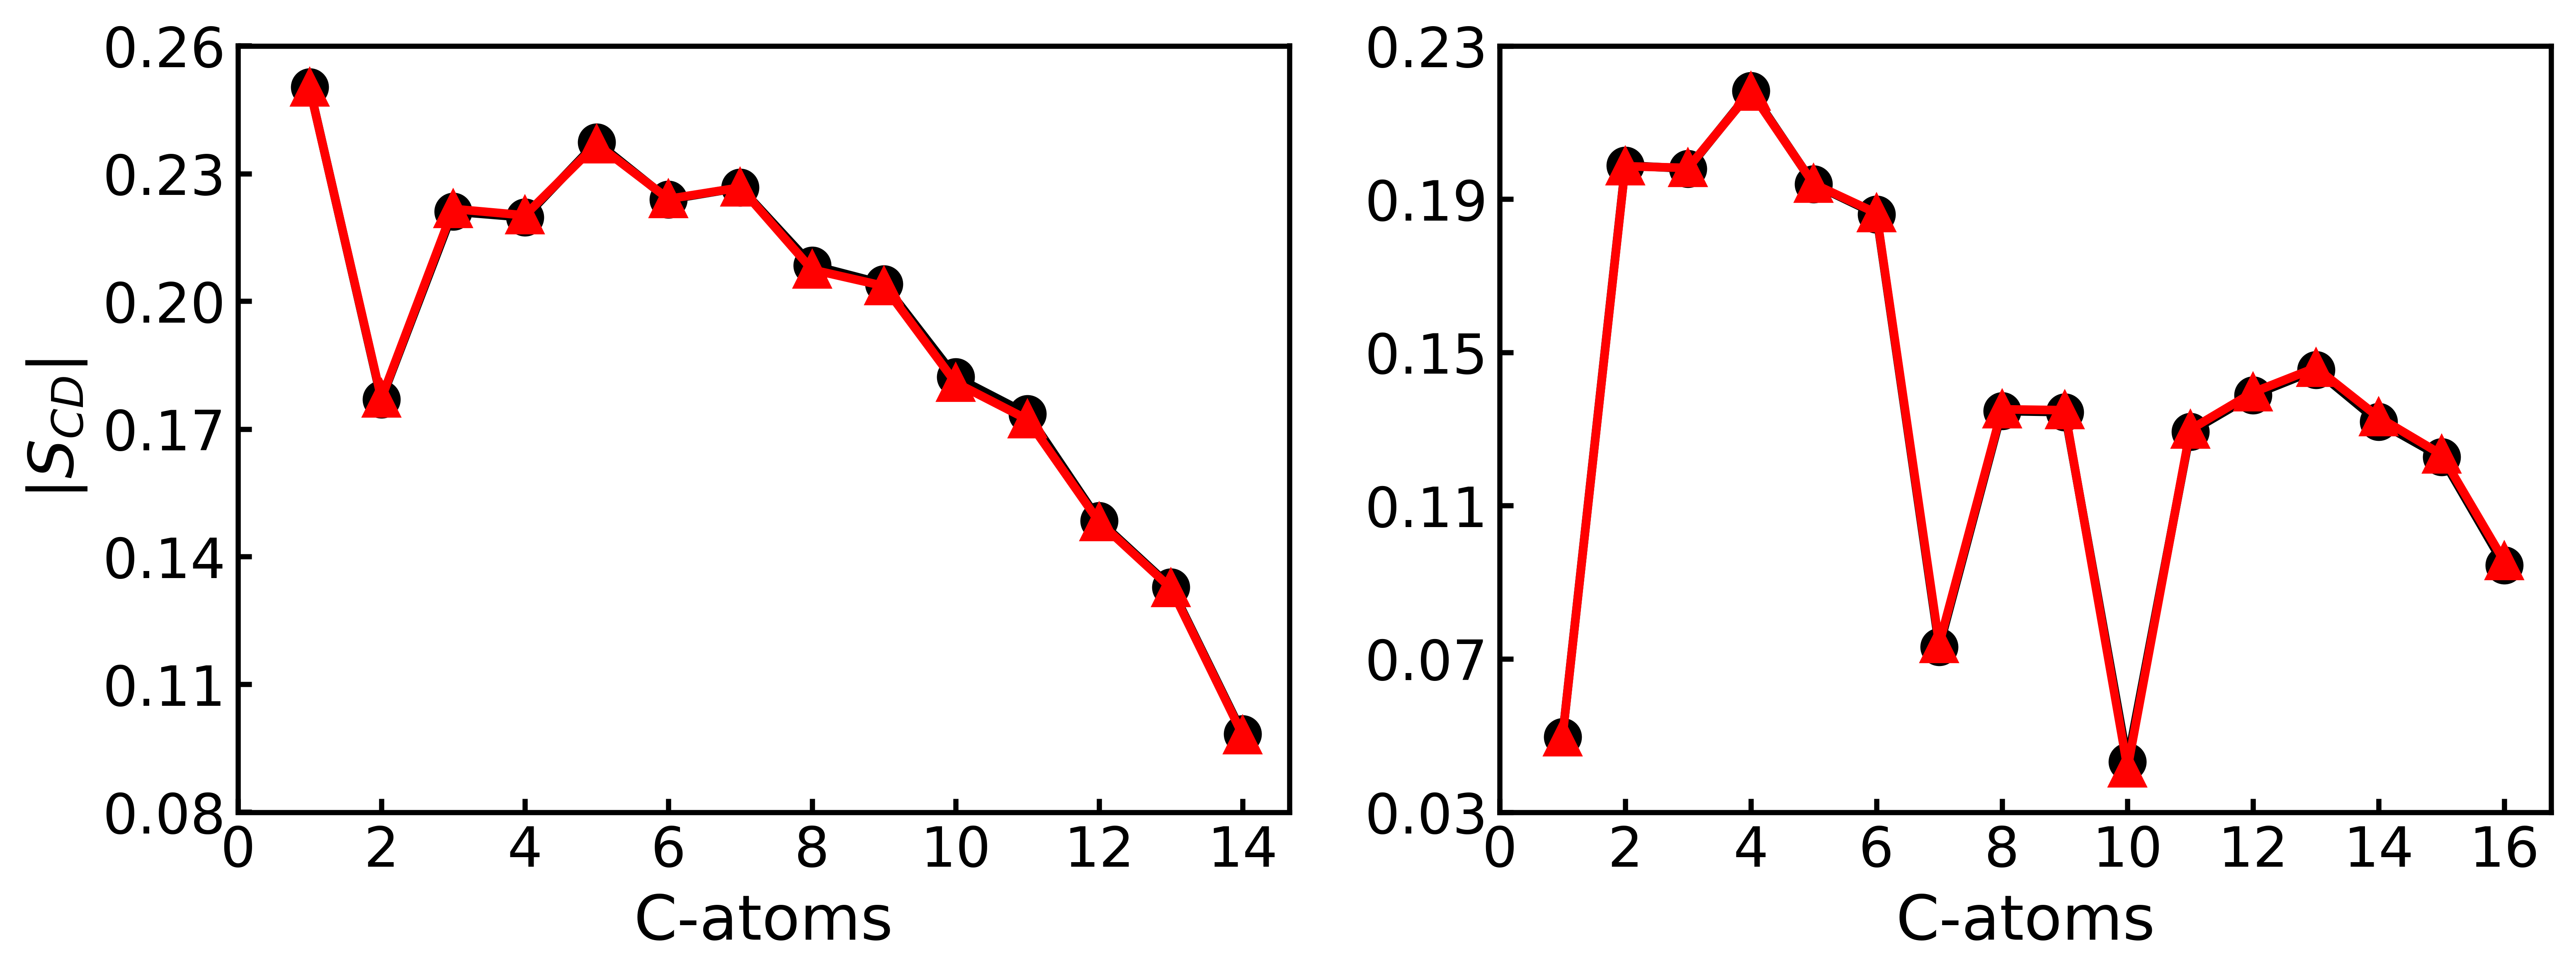

In [239]:
file=['1.Atomistic_simulations/2.POPC_in_water/analysis/order_parameter/op_sn1_popc.xvg',
      '1.Atomistic_simulations/3.POPC-PS/analysis/order_parameter/op_sn1_popc-ps.xvg',
      '1.Atomistic_simulations/2.POPC_in_water/analysis/order_parameter/op_sn2_popc.xvg',
      '1.Atomistic_simulations/3.POPC-PS/analysis/order_parameter/op_sn2_popc-ps.xvg']
dfs=[]
for filename in file:
    with open(filename) as f:
        lines=[line for line in f if not line.startswith(('#', '@'))]
    df1=pd.read_csv(StringIO(''.join(lines)), delim_whitespace=True, header=None, usecols=[0, 1])
    #print(df1[1])
    dfs.append(df1)

for i in range(4):
    dfs[i][1]=dfs[i][1]*-1

# GROUPS: (0,1) → SN1   and   (2,3) → SN2
groups = [(0, 1), (2, 3)]
labels = [('SN1', 'C-atom'), ('SN2', 'C-atom')]
colors = [('black', 'red'), ('black', 'red')]
markers = [('o', 's'), ('o', 's')]

# PLOT TWO SEPARATE FIGURES
#print(dfs[1][0])
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=600)

ax[0].plot(dfs[0][0], dfs[0][1], marker='o', markersize=10, color='black', linewidth=2.5)
ax[0].plot(dfs[1][0], dfs[1][1], marker='^', markersize=10, color='red', linewidth=2.5)

ax[1].plot(dfs[2][0], dfs[2][1], marker='o', markersize=10, color='black', linewidth=2.5)
ax[1].plot(dfs[3][0], dfs[3][1], marker='^', markersize=10, color='red', linewidth=2.5)

ax[0].tick_params(direction='in', labelsize=16, length=4, width=1.5)
ax[0].set_yticks(np.arange(0.08, 0.27, 0.03))
ax[0].set_xticks(np.arange(0, 15, 2))
ax[1].tick_params(direction='in', labelsize=16, length=4, width=1.5)
ax[1].set_yticks(np.arange(0.03, 0.27, 0.04))
ax[1].set_xticks(np.arange(0, 17, 2))

ax[0].set_xlabel('C-atoms', fontsize=18)
ax[0].set_ylabel('$|S_{CD}|$', fontsize=18)
ax[1].set_xlabel('C-atoms', fontsize=18)
#plt.tight_layout()
for spine in ax[0].spines.values():
    spine.set_linewidth(1.5)
for spine in ax[1].spines.values():
    spine.set_linewidth(1.5)

plt.savefig('popc-ps_popc_op.png', pad_inches=0.05, bbox_inches='tight', dpi=600)


<div style="font-size:22px; font-family:'Times New Roman'; font-weight:bold; margin-bottom: 20px;">
Coarse-grained simulations results
</div>
<div style="font-size:16px; font-family:'Times New Roman'; font-weight:normal;">
We calculated membrane thickness, area per lipid using the same method discussed in atomistic simulations results.
Here, we discuss the methods calculating area compressibility modulus and diffusion coefficient.


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

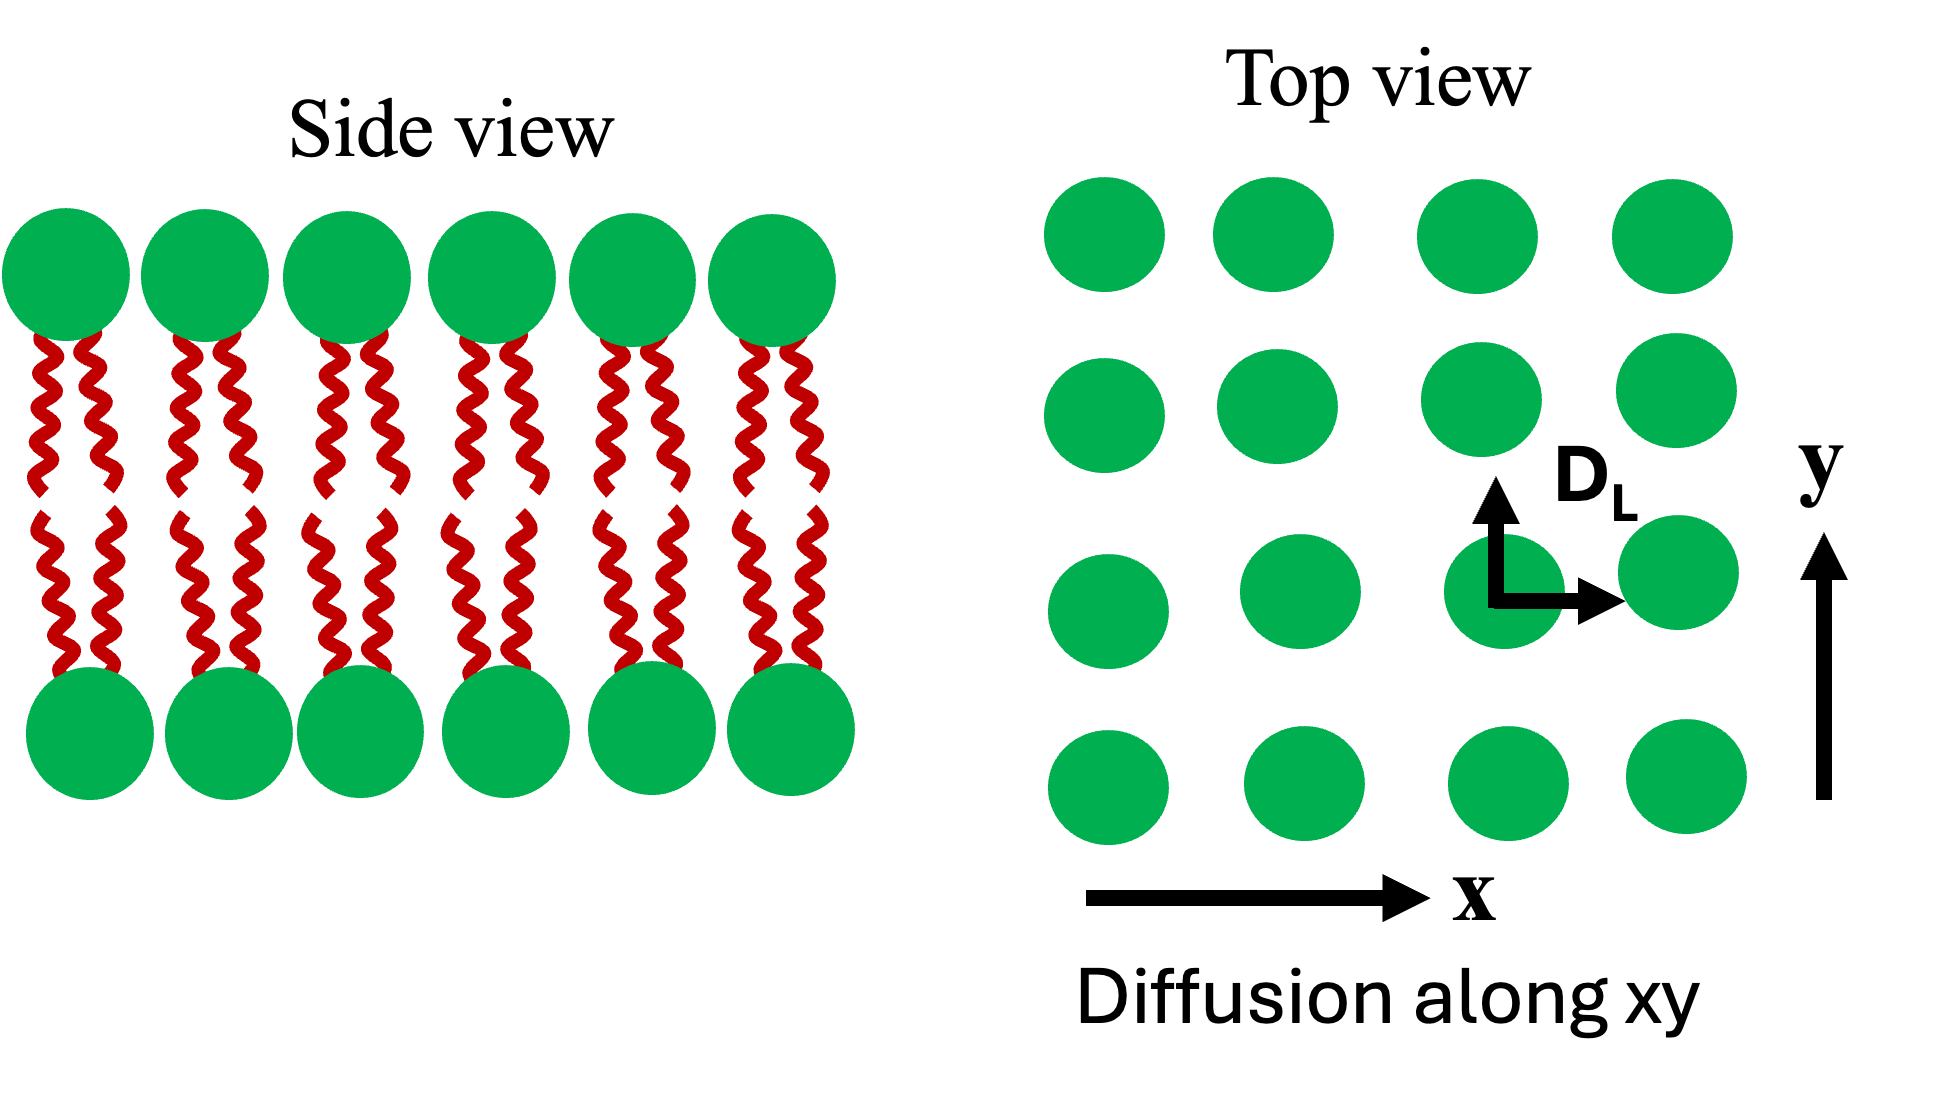

In [234]:
display(Markdown("""
<div style="font-size:22px; font-family:'Times New Roman'; font-weight:bold; margin-bottom: 20px;">
Coarse-grained simulations results
</div>
<div style="font-size:16px; font-family:'Times New Roman'; font-weight:normal;">
We calculated membrane thickness, area per lipid using the same method discussed in atomistic simulations results.
Here, we discuss the methods calculating area compressibility modulus and diffusion coefficient.
"""))

# Area compressibility modulus
display(Math(r"\textbf{Calculations of area compressibility modulus}"))
display(Math(r"K_A = \frac{k_B T \langle A \rangle}{\langle (\Delta A)^2 \rangle}"))

display(Math(r"K_A: \text{Area compressibility modulus of the membrane}"))
display(Math(r"k_B: \text{Boltzmann constant}"))
display(Math(r"T: \text{Temperature of the system}"))
display(Math(r"\langle A \rangle: \text{Average area of the membrane}"))
display(Math(r"\langle (\Delta A)^2 \rangle: \text{Variance in area fluctuations of the membrane}"))
display(Math(r"")) 

# Diffusion coefficient
display(Math(r"\textbf{Calculations of diffusion coefficient}"))
display(Math(r"D = \lim_{t \to \infty} \frac{ \left\langle \left\| \mathbf{r}(t) - \mathbf{r}(0) \right\|^2 \right\rangle }{2 d t}"))
# Definitions of variables
display(Math(r"\mathbf{r}(t):\text{Position vector at time } t"))
display(Math(r"\mathbf{r}(0):\text{Initial position vector}"))
display(Math(r"d:\text{Dimensionality of the system (e.g., } d=2 \text{ or } d=3 \text{)}"))
display(Math(r"\left\langle \cdots \right\rangle: \text{Ensemble and/or time average}"))
display(Math(r"D:\text{Diffusion coefficient (e.g., in } \text{nm}^2/\text{ns})"))
display(Math(r"\text{A schematic representation of the diffusion coefficient is shown below:}"))
display(Image(filename='1.Atomistic_simulations/diffusion_coefficient_schematic.png', width=400, height=300))


<div style="font-size:22px; font-family:'Times New Roman'; font-weight:bold; margin-bottom: 20px;">
Table 1: Calculations of membrane properties from POPC and POPC–PS systems from CG simulations


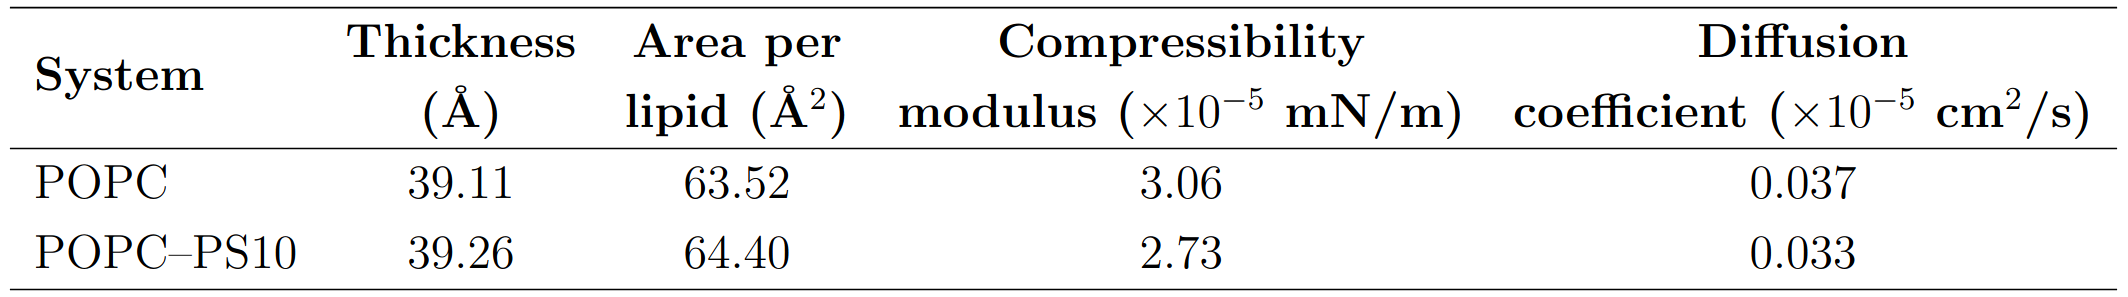

In [235]:
display(Markdown("""
<div style="font-size:22px; font-family:'Times New Roman'; font-weight:bold; margin-bottom: 20px;">
Table 1: Calculations of membrane properties from POPC and POPC–PS systems from CG simulations
"""))
display(Image(filename='2.Coarse-grained_simulations/3.POPC-PS/CG_analysis_table.png', width=1200, height=800))